# Grad-CAM Explainability — CA-CNN (4-Class Defect Detection)

**Model:** Custom CA-CNN (Phase 1 weights — `best_custom_ca_cnn_phase1.weights.h5`)  
**Target layer:** `trans_relu` — the last spatial feature map (14×14×128) before Global Average Pooling  

Grad-CAM highlights **which regions of the image** the model focused on when predicting a class.


---
## 1. Imports & Paths

In [1]:
print(5)

5


In [2]:
import os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

BASE       = os.getcwd()
TEST_DIR   = os.path.join(BASE, "splitted data", "test")
WEIGHTS    = os.path.join(BASE, "best_custom_ca_cnn_phase1.weights.h5")
CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]
IMG_SIZE   = (224, 224)

print(f"TensorFlow : {tf.__version__}")
print(f"Weights    : {'✅' if os.path.exists(WEIGHTS) else '❌'} {WEIGHTS}")

2026-05-29 16:55:49.943742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780070150.060892   18077 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780070150.093108   18077 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-29 16:55:50.364884: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow : 2.18.0
Weights    : ✅ /home/feriel/PFE/Defect-Detection/best_custom_ca_cnn_phase1.weights.h5


---
## 2. Rebuild CA-CNN & Load Phase-1 Weights

In [3]:
# ── Coordinate Attention ─────────────────────────────────────────────────────
class CoordinateAttention(layers.Layer):
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs); self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]; mid = max(8, C // self.reduction)
        self.shared_conv = layers.Conv2D(mid, 1, padding="same", use_bias=False)
        self.bn           = layers.BatchNormalization()
        self.relu         = layers.ReLU(max_value=6.0)
        self.conv_h       = layers.Conv2D(C, 1, padding="same")
        self.conv_w       = layers.Conv2D(C, 1, padding="same")
        super().build(input_shape)

    def call(self, x, training=False):
        H    = tf.shape(x)[1]
        ph   = tf.reduce_mean(x, axis=2, keepdims=True)
        pw   = tf.transpose(tf.reduce_mean(x, axis=1, keepdims=True), [0,2,1,3])
        y    = self.relu(self.bn(self.shared_conv(tf.concat([ph, pw], 1)), training=training))
        a_h  = tf.sigmoid(self.conv_h(y[:, :H, :, :]))
        a_w  = tf.transpose(tf.sigmoid(self.conv_w(y[:, H:, :, :])), [0,2,1,3])
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config(); cfg["reduction"] = self.reduction; return cfg


# ── Inverse Residual Block ────────────────────────────────────────────────────
def inv_res_block(x, out_ch, stride=1, expand=6, pfx="irb"):
    in_ch = x.shape[-1]; skip = x
    if expand != 1:
        x = layers.Conv2D(in_ch*expand,1,padding="same",use_bias=False,name=f"{pfx}_expand_conv")(x)
        x = layers.BatchNormalization(name=f"{pfx}_expand_bn")(x)
        x = layers.ReLU(6.0, name=f"{pfx}_expand_relu")(x)
    x = layers.DepthwiseConv2D(3,strides=stride,padding="same",use_bias=False,name=f"{pfx}_dw_conv")(x)
    x = layers.BatchNormalization(name=f"{pfx}_dw_bn")(x)
    x = layers.ReLU(6.0, name=f"{pfx}_dw_relu")(x)
    x = CoordinateAttention(32, name=f"{pfx}_ca")(x)
    x = layers.Conv2D(out_ch,1,padding="same",use_bias=False,name=f"{pfx}_proj_conv")(x)
    x = layers.BatchNormalization(name=f"{pfx}_proj_bn")(x)
    if stride == 1 and in_ch == out_ch:
        x = layers.Add(name=f"{pfx}_add")([skip, x])
    return x


# ── Build full model ──────────────────────────────────────────────────────────
def build_ca_cnn():
    inp = layers.Input((224,224,3), name="input")
    x   = layers.Conv2D(32,3,strides=2,padding="same",use_bias=False,name="stem_conv")(inp)
    x   = layers.BatchNormalization(name="stem_bn")(x)
    x   = layers.ReLU(6.0, name="stem_relu")(x)
    x   = inv_res_block(x, 16, stride=1, expand=1, pfx="irb1")
    x   = inv_res_block(x, 24, stride=2, expand=6, pfx="irb2")
    x   = inv_res_block(x, 32, stride=2, expand=6, pfx="irb3")
    x   = inv_res_block(x, 64, stride=2, expand=6, pfx="irb4")
    x   = inv_res_block(x, 96, stride=1, expand=6, pfx="irb5")
    x   = layers.Conv2D(128,1,padding="same",use_bias=False,name="trans_conv")(x)
    x   = layers.BatchNormalization(name="trans_bn")(x)
    x   = layers.ReLU(6.0, name="trans_relu")(x)       # ← Grad-CAM target layer
    x   = layers.GlobalAveragePooling2D(name="gap")(x)
    x   = layers.Dense(256, activation="relu", name="fc1")(x)
    x   = layers.Dropout(0.3, name="drop")(x)
    out = layers.Dense(4, activation="softmax", name="predictions")(x)
    return keras.Model(inp, out, name="CA_CNN")


model = build_ca_cnn()
model.load_weights(WEIGHTS)
model.trainable = False
print(f"CA-CNN loaded — {model.count_params():,} params")
print(f"Grad-CAM target layer: 'trans_relu'  output shape: {model.get_layer('trans_relu').output.shape}")

I0000 00:00:1780070157.290300   18077 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


CA-CNN loaded — 182,180 params
Grad-CAM target layer: 'trans_relu'  output shape: (None, 14, 14, 128)


---
## 3. Load Test Image Paths & Labels

In [4]:
def get_paths_labels(folder):
    paths, labels = [], []
    cls_map = {c: i for i, c in enumerate(CLASS_NAMES)}
    for cls in CLASS_NAMES:
        d = os.path.join(folder, cls)
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            if f.lower().endswith((".jpg",".jpeg",".png")):
                paths.append(os.path.join(d, f))
                labels.append(cls_map[cls])
    return np.array(paths), np.array(labels)


def load_img(path):
    """Load image → float32 (1,224,224,3) in [0,1] for model, (224,224,3) for display."""
    raw  = tf.io.read_file(path)
    img  = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img  = tf.image.resize(img, IMG_SIZE)
    img  = tf.cast(img, tf.float32) / 255.0
    return img.numpy()                    # (224,224,3)


test_paths, test_labels = get_paths_labels(TEST_DIR)
print(f"Test images: {len(test_paths)}")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<12} {(test_labels == i).sum()} images")

Test images: 776
  Cracking     167 images
  Stringing    256 images
  Warping      171 images
  No_Defect    182 images


---
## 4. Grad-CAM Implementation

Standard Grad-CAM pipeline (Selvaraju et al., 2017):  
gradients → global-average-pool → weight activations → ReLU → resize → overlay

In [5]:
# Sub-model that outputs [target_layer_activations, final_predictions]
gradcam_model = keras.Model(
    inputs  = model.input,
    outputs = [model.get_layer("trans_relu").output, model.output],
)


def compute_gradcam(img_np, class_idx=None):
    """
    img_np     : (224,224,3) float32 in [0,1]
    class_idx  : which class to explain (None → use predicted class)

    Returns
    -------
    cam        : (224,224) float32 in [0,1]  — the Grad-CAM heatmap
    pred_idx   : predicted class index
    pred_conf  : predicted class confidence (%)
    """
    inp = tf.constant(img_np[np.newaxis, ...])   # (1,224,224,3)

    with tf.GradientTape() as tape:
        tape.watch(inp)
        activations, preds = gradcam_model(inp, training=False)
        pred_idx  = int(tf.argmax(preds[0]))
        pred_conf = float(preds[0][pred_idx]) * 100
        if class_idx is None:
            class_idx = pred_idx
        score = preds[:, class_idx]              # scalar — the class logit

    # Gradients of the score w.r.t. the activation map
    grads   = tape.gradient(score, activations)  # (1,14,14,128)

    # Global-average-pool the gradients → (128,)
    weights = tf.reduce_mean(grads, axis=[0, 1, 2])

    # Weighted sum of activation channels → (14,14)
    cam = tf.reduce_sum(activations[0] * weights, axis=-1).numpy()

    # ReLU + normalise to [0,1]
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam /= cam.max()

    # Resize to input resolution
    cam = tf.image.resize(cam[..., np.newaxis], IMG_SIZE).numpy()[..., 0]

    return cam, pred_idx, pred_conf


def overlay_heatmap(img_np, cam, alpha=0.45):
    """Blend the jet heatmap on top of the original image."""
    heatmap = cm.jet(cam)[..., :3]                          # (224,224,3) RGB
    overlay = (1 - alpha) * img_np + alpha * heatmap
    return np.clip(overlay, 0, 1)


print("✅ Grad-CAM functions ready.")

✅ Grad-CAM functions ready.


---
## 5. Grad-CAM on Correctly Classified Images

**Grid layout:** 4 rows (one per class) × 3 columns (Original | Heatmap | Overlay)  
We pick the **2 most-confident correctly classified images per class** and show one.

Running predictions on test set …


I0000 00:00:1780070169.186335   18077 cuda_dnn.cc:529] Loaded cuDNN version 92000


Done. Overall accuracy: 99.87%
  Cracking     → conf=100.0%  file=Cracking (275).jpg
  Stringing    → conf=100.0%  file=Stringing (2477).jpg
  Warping      → conf=100.0%  file=warped (900).jpg
  No_Defect    → conf=100.0%  file=No_Stringing (1653).jpg


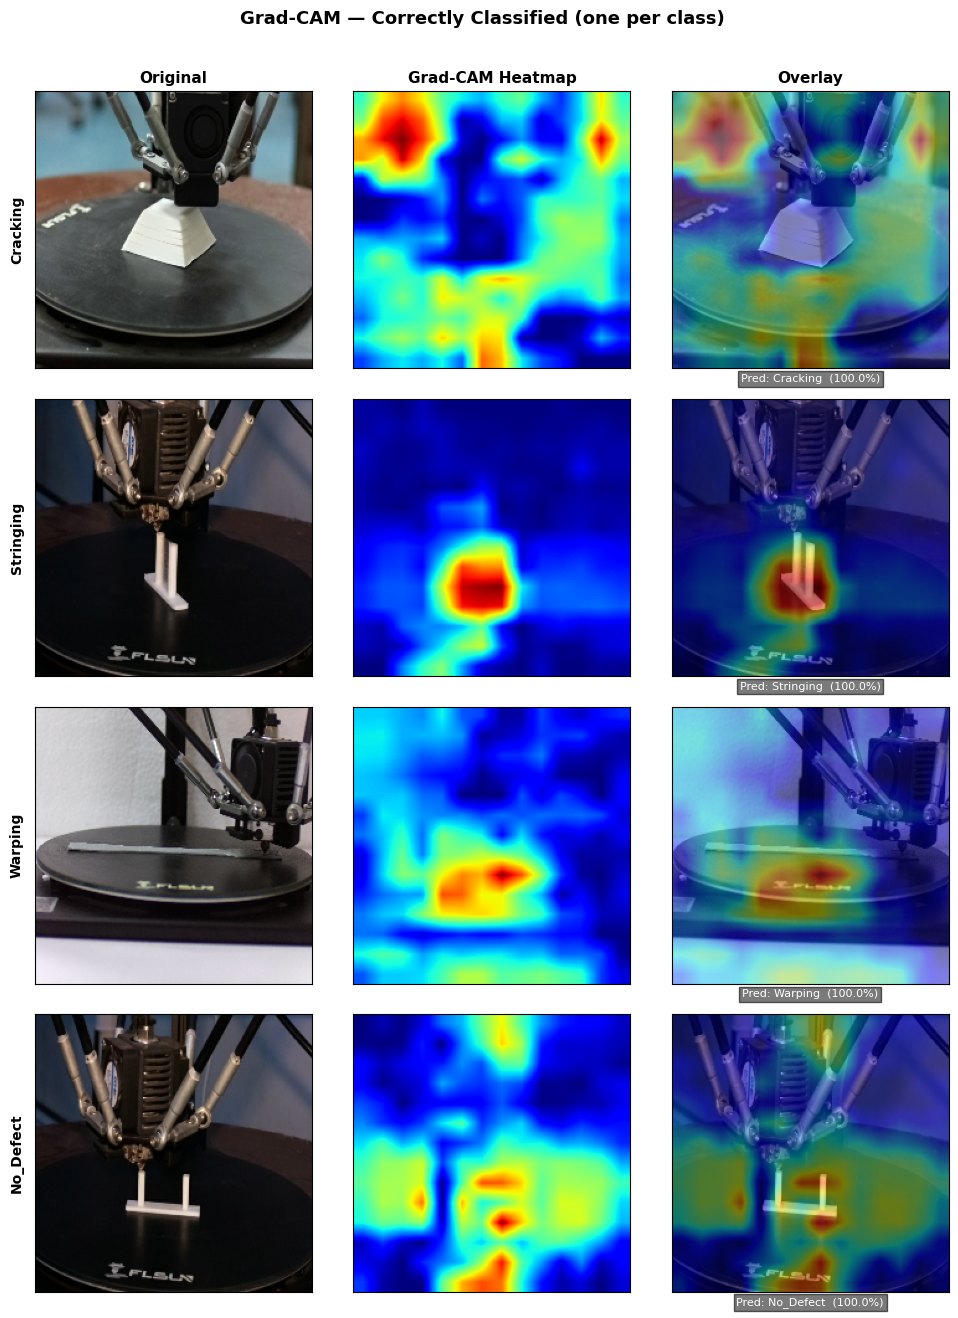

Saved → /home/feriel/PFE/Defect-Detection/gradcam_correct.png


In [6]:
# ── Step 1: run predictions on the full test set ─────────────────────────────
print("Running predictions on test set …")
all_preds, all_confs = [], []
BATCH = 32
for i in range(0, len(test_paths), BATCH):
    batch = np.array([load_img(p) for p in test_paths[i:i+BATCH]], dtype=np.float32)
    probs = model(batch, training=False).numpy()
    all_preds.extend(np.argmax(probs, axis=1).tolist())
    all_confs.extend(np.max(probs, axis=1).tolist())
all_preds = np.array(all_preds)
all_confs = np.array(all_confs)
print(f"Done. Overall accuracy: {(all_preds == test_labels).mean()*100:.2f}%")


# ── Step 2: pick 1 top-confidence correct image per class ─────────────────────
selected_correct = {}   # class_idx → (path, img_np, cam, pred_idx, conf)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask    = (test_labels == cls_idx) & (all_preds == cls_idx)   # correct
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f"  No correct samples for {cls_name}!"); continue

    # Sort by confidence descending, take the best one
    best_idx = indices[np.argsort(all_confs[indices])[::-1][0]]
    path     = test_paths[best_idx]
    img_np   = load_img(path)
    cam, pred_idx, conf = compute_gradcam(img_np)
    selected_correct[cls_idx] = (path, img_np, cam, pred_idx, conf)
    print(f"  {cls_name:<12} → conf={conf:.1f}%  file={os.path.basename(path)}")


# ── Step 3: draw 4×3 grid ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
fig.suptitle("Grad-CAM — Correctly Classified (one per class)",
             fontsize=13, fontweight="bold", y=1.01)

col_titles = ["Original", "Grad-CAM Heatmap", "Overlay"]
for j, ct in enumerate(col_titles):
    axes[0][j].set_title(ct, fontsize=11, fontweight="bold")

for row, (cls_idx, cls_name) in enumerate(zip(range(4), CLASS_NAMES)):
    if cls_idx not in selected_correct:
        for ax in axes[row]: ax.axis("off")
        continue
    _, img_np, cam, pred_idx, conf = selected_correct[cls_idx]
    heat  = cm.jet(cam)[..., :3]
    over  = overlay_heatmap(img_np, cam)

    axes[row][0].imshow(img_np)
    axes[row][0].set_ylabel(cls_name, fontsize=10, fontweight="bold", rotation=90, labelpad=8)

    axes[row][1].imshow(heat)
    axes[row][2].imshow(over)

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

    # Confidence annotation on overlay
    axes[row][2].set_xlabel(f"Pred: {CLASS_NAMES[pred_idx]}  ({conf:.1f}%)",
                            fontsize=8, color="white",
                            bbox=dict(facecolor="#222", alpha=0.6, pad=2))

plt.tight_layout()
out_path = os.path.join(BASE, "gradcam_correct.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

---
## 6. Grad-CAM on Misclassified Images

Grad-CAM on wrong predictions reveals **where the model looked when it made a mistake** —
useful for understanding model failures and discussing limitations.


Total misclassified: 1 | showing top 1


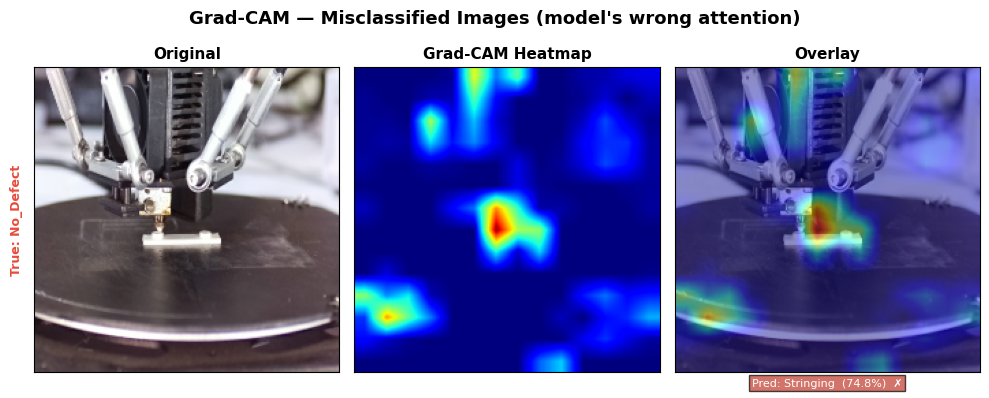

Saved → /home/feriel/PFE/Defect-Detection/gradcam_wrong.png


In [7]:
# Pick up to 3 misclassified images (highest confidence wrong predictions)
wrong_mask    = (all_preds != test_labels)
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) == 0:
    print("No misclassified images found — model is perfect on this test set!")
else:
    # Sort by confidence (most "confident wrong" first)
    sorted_wrong = wrong_indices[np.argsort(all_confs[wrong_indices])[::-1]]
    top_wrong    = sorted_wrong[:3]
    print(f"Total misclassified: {len(wrong_indices)} | showing top {len(top_wrong)}")

    fig, axes = plt.subplots(len(top_wrong), 3,
                             figsize=(10, len(top_wrong) * 3.3 + 0.5))
    if len(top_wrong) == 1:
        axes = axes[np.newaxis, :]   # keep 2-D

    fig.suptitle("Grad-CAM — Misclassified Images (model's wrong attention)",
                 fontsize=13, fontweight="bold", y=1.01)

    for j, ct in enumerate(["Original", "Grad-CAM Heatmap", "Overlay"]):
        axes[0][j].set_title(ct, fontsize=11, fontweight="bold")

    for row, idx in enumerate(top_wrong):
        path       = test_paths[idx]
        true_cls   = CLASS_NAMES[test_labels[idx]]
        img_np     = load_img(path)
        cam, pred_idx, conf = compute_gradcam(img_np)
        heat = cm.jet(cam)[..., :3]
        over = overlay_heatmap(img_np, cam)

        axes[row][0].imshow(img_np)
        axes[row][0].set_ylabel(
            f"True: {true_cls}", fontsize=9, fontweight="bold",
            color="#e74c3c", rotation=90, labelpad=8
        )
        axes[row][1].imshow(heat)
        axes[row][2].imshow(over)
        axes[row][2].set_xlabel(
            f"Pred: {CLASS_NAMES[pred_idx]}  ({conf:.1f}%)  ✗",
            fontsize=8, color="white",
            bbox=dict(facecolor="#c0392b", alpha=0.7, pad=2)
        )

        for ax in axes[row]:
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    out_path = os.path.join(BASE, "gradcam_wrong.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")